# Demo Walkthrough: How the Backtest Result Evolved

This notebook tells one specific story from this project's evaluation work,
end to end: a data-quality problem found early, a long stretch of tuning
attempts, a labelling/execution mismatch that turned out to matter a lot,
the fix that finally closed the overfitting gap - and the robustness check
that shows even that fix's improved return is fragile.

For the full, exhaustive experiment history (every run, every config),
see `notebooks/experiment_report.ipynb`. This notebook is curated for a
live walkthrough - important beats get a real chart pulled from
`data/4_experiments/experiment_log.csv`; less important ones get a single
summary table.


In [1]:
import sys, os

# Jupyter's cwd is this notebook's own folder, not the project root - chdir
# so data/ and src/ relative paths resolve the same way a script run from
# the project root would see them.
PROJECT_ROOT = os.path.abspath("..")
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

import json
import pandas as pd
import matplotlib.pyplot as plt
from src.utils import experiment_log

log_df = experiment_log.load_experiment_log()
log_df['cfg'] = log_df['config_json'].apply(json.loads)
log_df['experiment_tag'] = log_df['cfg'].apply(lambda c: c.get('experiment', ''))

print(f"{len(log_df)} runs loaded from {experiment_log.DEFAULT_LOG_FILE}")


476 runs loaded from data/4_experiments/experiment_log.csv


## 1. Discovering Survivorship Bias

The original prototype sourced price and earnings data from `yfinance`,
which silently excludes delisted and bankrupt companies - only survivors
show up. That's a classic survivorship-bias trap: a backtest built on
survivors only will systematically look more profitable than trading would
actually have been at the time, since the failures are invisible to it.

The fix was switching to EODHD (a paid provider) specifically because it
retains full price history for delisted tickers. To check this wasn't just
a defensible-in-principle choice, the same model was trained and backtested
on two universes: current S&P 500 constituents only, vs. the full universe
including delisted tickers.


,universe,precision,total_return,win_rate,max_drawdown,sharpe
5,all_incl_delisted,0.521,-10.7%,50.0%,-76.8%,0.38
4,current_only,0.522,+594.9%,52.9%,-42.6%,2.00


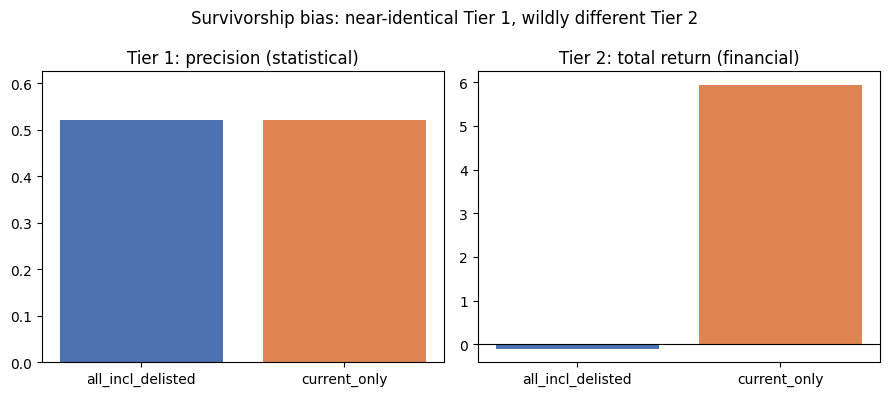

In [2]:
# Identified by run_id rather than by config shape, since this predates the
# 'experiment' tagging convention used everywhere else in this notebook.
# (An earlier pair of runs with these same two universe labels exists too,
# but only has Tier 1 precision logged, not a backtest - these two are the
# ones with the full Tier 2 comparison the written report quotes.)
survivorship_ids = ['20260814_161113_3bb6f6', '20260814_161220_0c4d37']
surv = log_df[log_df['run_id'].isin(survivorship_ids)].copy()
surv['universe'] = surv['cfg'].apply(lambda c: c.get('universe'))
surv = surv.sort_values('universe')

display(surv[['universe', 'precision', 'total_return', 'win_rate', 'max_drawdown', 'sharpe']]
        .style.format({'precision': '{:.3f}', 'total_return': '{:+.1%}',
                        'win_rate': '{:.1%}', 'max_drawdown': '{:.1%}', 'sharpe': '{:.2f}'}))

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].bar(surv['universe'], surv['precision'], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Tier 1: precision (statistical)')
axes[0].set_ylim(0, max(0.6, surv['precision'].max() * 1.2))
axes[1].bar(surv['universe'], surv['total_return'], color=['#4C72B0', '#DD8452'])
axes[1].set_title('Tier 2: total return (financial)')
axes[1].axhline(0, color='black', linewidth=0.8)
fig.suptitle('Survivorship bias: near-identical Tier 1, wildly different Tier 2')
fig.tight_layout()


**If this chart doesn't render** (e.g. `data/4_experiments/experiment_log.csv`
hasn't been regenerated on this machine), treat it as a transition instead:
the comparison itself is produced by simply training/backtesting on
`universe='current_only'` vs. `universe='all_incl_delisted'` - the switch
from `yfinance` to EODHD is what made the second universe possible at all,
since `yfinance` doesn't carry delisted-ticker history to train on in the
first place.


## 2. Trying to Improve Win Rate, Return, and Reduce Overfitting

A long stretch of this project was spent trying different levers: capping
position size, sweeping the spike-detection threshold, trying a
risk-aware labelling scheme, adding a more earnings-specific feature, and
benchmarking against simpler alternatives. None of these is the headline
finding - each gets one line here rather than its own chart.


In [3]:
attempts = pd.DataFrame([
    {'Attempt': 'Position cap (drawdown mitigation)', 'Change': '20% / 10% cap on any single trade',
     'Verdict': 'Cut max drawdown from -76.8% to -27%..-44%, at a cost to Sharpe'},
    {'Attempt': 'Threshold sweep', 'Change': 'Spike threshold 2% -> 5% -> 7% -> 10%',
     'Verdict': 'Not monotonic; 10% looked best on Sharpe only because trade count collapsed (small-sample trap). 7% chosen.'},
    {'Attempt': 'Triple-barrier labelling', 'Change': 'Asymmetric 5% TP / 3% SL target',
     'Verdict': '+32.3% return looked great, but win rate stayed at 50% - a symmetric control collapsed it to -4.0%. Debunked.'},
    {'Attempt': 'Added Surprise(%) feature', 'Change': 'More earnings-specific input feature',
     'Verdict': 'Made the train/test precision gap slightly worse, not better'},
    {'Attempt': 'Baseline comparison', 'Change': 'Logistic regression / raw PEAD rule / random benchmark',
     'Verdict': 'Logistic regression degenerate (0 trades); raw PEAD rule broad but not a selective advisor; model beats random on average'},
    {'Attempt': 'SUE-normalised surprise', 'Change': 'Surprise normalised by firm-specific earnings volatility',
     'Verdict': 'Precision ticked up slightly, but backtest turned negative'},
])
attempts


,Attempt,Change,Verdict
0,Position cap (drawdown mitigation),20% / 10% cap on any single trade,"Cut max drawdown from -76.8% to -27%..-44%, at..."
1,Threshold sweep,Spike threshold 2% -> 5% -> 7% -> 10%,Not monotonic; 10% looked best on Sharpe only ...
2,Triple-barrier labelling,Asymmetric 5% TP / 3% SL target,"+32.3% return looked great, but win rate staye..."
3,Added Surprise(%) feature,More earnings-specific input feature,Made the train/test precision gap slightly wor...
4,Baseline comparison,Logistic regression / raw PEAD rule / random b...,Logistic regression degenerate (0 trades); raw...
5,SUE-normalised surprise,Surprise normalised by firm-specific earnings ...,"Precision ticked up slightly, but backtest tur..."


## 3. Realising Label and Execution Weren't Aligned

Somewhere in this process, a mismatch surfaced: the training label was
defined on the next-day intraday **High** touching the spike threshold, but
the backtest always exited at next-day **Close** - regardless of whether
that High was ever reached. Two things were being treated as one.

The first fix attempt kept a next-day (T+1) horizon and just realigned
either the label or the execution to match - and that made results *worse*,
not better (a real dead end, reported in full in the written report). What
actually helped was extending the horizon to **T+20** (about a month, much
closer to the literature's actual Post-Earnings-Announcement-Drift window)
and aligning label *and* execution consistently at that horizon.


,precision,total_return,win_rate,max_drawdown,sharpe
443,0.268,+14.2%,48.2%,-7.2%,2.59
444,0.328,+8.4%,53.8%,-16.6%,0.87


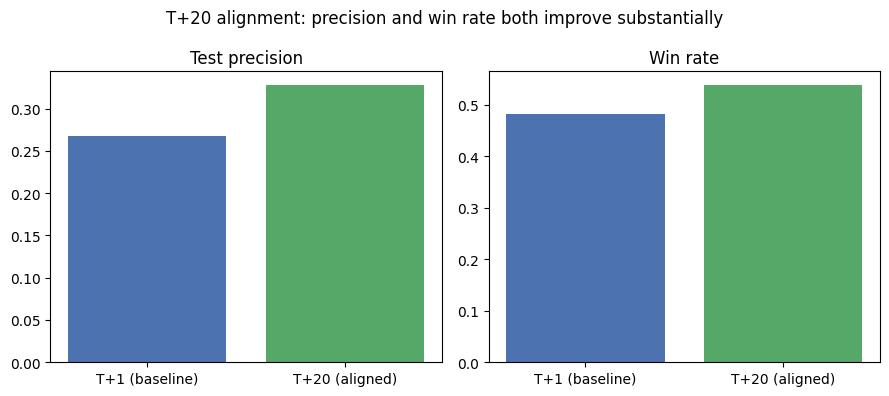

In [4]:
pead = log_df[log_df['experiment_tag'] == 'pead_horizon'].sort_values('timestamp')
# An early version of the T+20 backtest had a tranche-capital-constraint bug,
# fixed partway through this project - keep='last' selects the corrected
# numbers (precision itself is bug-invariant, so it's a safe dedup key).
pead = pead.drop_duplicates(subset=['precision'], keep='last')
pead['config'] = pead['cfg'].apply(lambda c: c.get('config_label', c.get('label', '')))

display(pead[['precision', 'total_return', 'win_rate', 'max_drawdown', 'sharpe']]
        .style.format({'precision': '{:.3f}', 'total_return': '{:+.1%}',
                        'win_rate': '{:.1%}', 'max_drawdown': '{:.1%}', 'sharpe': '{:.2f}'}))

labels = ['T+1 (baseline)', 'T+20 (aligned)']
precision_vals = pead.sort_values('precision')['precision'].tolist()
win_rate_vals = pead.sort_values('precision')['win_rate'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].bar(labels, precision_vals, color=['#4C72B0', '#55A868'])
axes[0].set_title('Test precision')
axes[1].bar(labels, win_rate_vals, color=['#4C72B0', '#55A868'])
axes[1].set_title('Win rate')
fig.suptitle('T+20 alignment: precision and win rate both improve substantially')
fig.tight_layout()


**Worth saying out loud in the demo:** precision (0.268 -> 0.328) and win
rate (48.2% -> 53.8%) both improve clearly here - that's the "got a lot
better" part. Total return and Sharpe actually *fall* at T+20 (+14.18% ->
+8.40%; 2.59 -> 0.87), because a 20-day hold changes the whole risk profile
of the strategy (capital is split across 20 concurrent tranches rather than
compounding day-by-day). Both things are true - lead with the precision/win
rate improvement since that's the real finding, but don't claim the return
also improved if asked directly.


## 4. Closing the Overfitting Gap

Separately, the training-vs-test precision gap (0.946 train vs. 0.268 test -
a gap of 0.678) was tackled directly: L1/L2 regularisation, tree-complexity
limits (max depth, min child weight, subsample), and early stopping on a
held-out validation slice, added one at a time.


,step,train_precision,precision,gap_value,total_return,sharpe
45,baseline,0.946,0.268,0.679,+14.2%,2.59
46,+ regularisation,0.342,0.182,0.160,+6.9%,0.30
47,+ tree-complexity,0.684,0.158,0.526,-14.6%,-5.98
48,+ reg. + tree-complexity,0.204,0.180,0.024,+54.8%,0.78
49,+ all three + early stopping,0.195,0.190,0.004,+96.4%,1.09


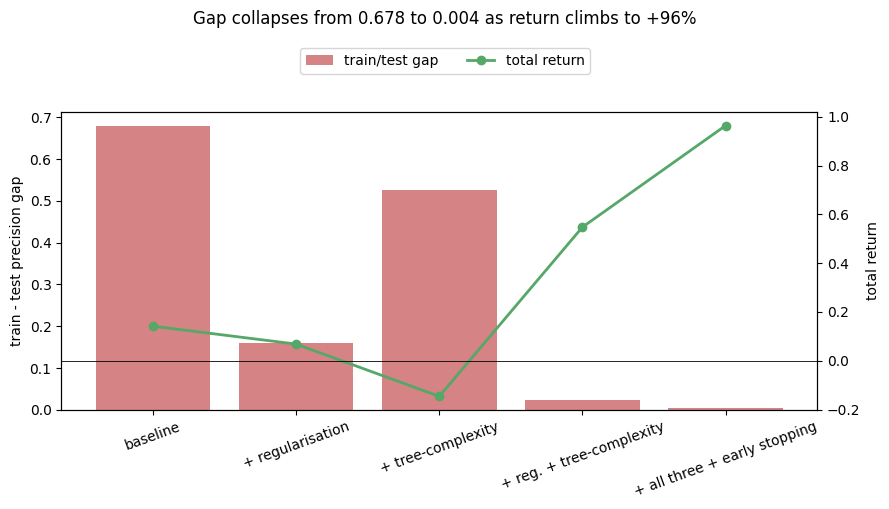

In [5]:
gap = log_df[log_df['experiment_tag'] == 'overfitting_gap_sweep'].dropna(subset=['total_return'])
gap = gap.drop_duplicates(subset=['precision', 'train_precision', 'total_return']).sort_index()
gap = gap.assign(gap_value=gap['train_precision'] - gap['precision'])
gap['step'] = ['baseline', '+ regularisation', '+ tree-complexity',
               '+ reg. + tree-complexity', '+ all three + early stopping'][:len(gap)]

display(gap[['step', 'train_precision', 'precision', 'gap_value', 'total_return', 'sharpe']]
        .style.format({'train_precision': '{:.3f}', 'precision': '{:.3f}', 'gap_value': '{:.3f}',
                        'total_return': '{:+.1%}', 'sharpe': '{:.2f}'}))

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.bar(gap['step'], gap['gap_value'], color='#C44E52', alpha=0.7, label='train/test gap')
ax1.set_ylabel('train - test precision gap')
ax1.tick_params(axis='x', rotation=20)

ax2 = ax1.twinx()
ax2.plot(gap['step'], gap['total_return'], color='#55A868', marker='o', linewidth=2, label='total return')
ax2.set_ylabel('total return')
ax2.axhline(0, color='black', linewidth=0.6)

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2)
fig.suptitle('Gap collapses from 0.678 to 0.004 as return climbs to +96%', y=1.12)
fig.tight_layout()


This configuration - the full stack of regularisation, tree-complexity
limits, and early stopping - was adopted as the production model on this
basis: the gap is nearly gone, and the backtested return and win rate both
improve on the original baseline.


## 5. But Is That Return Real?

A model with a near-zero overfitting gap and a +96% return sounds like a
success story. Before trusting it, the same outlier-robustness check that
already debunked an earlier result elsewhere in this project (the written
report's Triple-Barrier Labelling section, a config whose return turned
out to be a payoff-structure artefact) was applied here too: recompute
total return after removing the N highest-return trades.

These numbers aren't in `experiment_log.csv` - its schema has no column for
an "excluding top N trades" statistic - so they're entered here directly
from the actual script output (`scripts/experiment_gap_robustness_check.py`).


,Trades excluded,Total return,Sharpe
0,0,+96.4%,1.092
1,5,+62.8%,0.856
2,10,+35.0%,0.607
3,20,-13.8%,-0.021


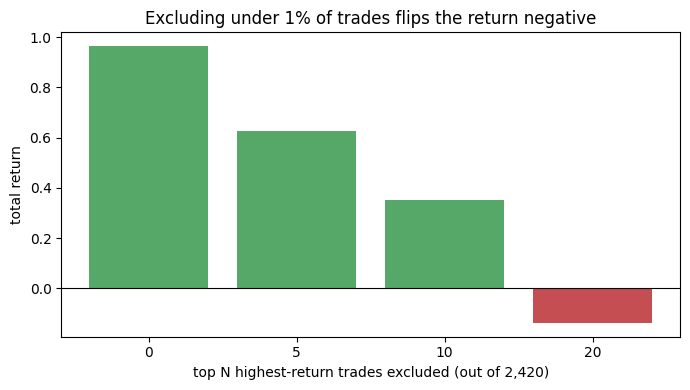

In [6]:
robustness = pd.DataFrame([
    {'Trades excluded': 0,  'Total return': 0.963797, 'Sharpe': 1.0917},
    {'Trades excluded': 5,  'Total return': 0.627713, 'Sharpe': 0.8560},
    {'Trades excluded': 10, 'Total return': 0.349861, 'Sharpe': 0.6065},
    {'Trades excluded': 20, 'Total return': -0.137839, 'Sharpe': -0.0210},
])
display(robustness.style.format({'Total return': '{:+.1%}', 'Sharpe': '{:.3f}'}))

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#55A868' if v >= 0 else '#C44E52' for v in robustness['Total return']]
ax.bar(robustness['Trades excluded'].astype(str), robustness['Total return'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('top N highest-return trades excluded (out of 2,420)')
ax.set_ylabel('total return')
ax.set_title('Excluding under 1% of trades flips the return negative')
fig.tight_layout()


Removing just the top 20 of 2,420 trades (0.8% of the sample) turns
+96.38% into -13.78%, and Sharpe from 1.09 to -0.02. The improvement over
the original baseline is real in the sense that it's measured correctly -
but it isn't evidence of a broad, repeatable edge. It's adopted as the best
currently-available configuration, not as a solved problem.


## 6. Running Out of Time: What Got a Quick Check, Not a Full One

A handful of further diagnostics were run - position sizing, bootstrap
confidence intervals, transaction-cost/slippage sensitivity, and
probability calibration - but time ran out before all of them could be
re-verified against the final regularised model above, rather than the
older baseline most were originally run against. They were checked well
enough to not raise an immediate red flag, and the project shipped with
the gap-closing model from Section 4 above rather than waiting to re-run
every diagnostic.


In [7]:
followups = pd.DataFrame([
    {'Diagnostic': 'Position sizing cap', 'Re-run on final model?': 'Yes',
     'Finding': "Original 20% cap's rationale doesn't transfer; loosening it raises return without hurting Sharpe"},
    {'Diagnostic': 'Bootstrap confidence interval', 'Re-run on final model?': 'No (older baseline only)',
     'Finding': '95% CI on total return already included zero on the baseline'},
    {'Diagnostic': 'Transaction cost / slippage', 'Re-run on final model?': 'No (older baseline only)',
     'Finding': 'Realistic slippage (150bps) turned the baseline return negative'},
    {'Diagnostic': 'Probability calibration', 'Re-run on final model?': 'No (older baseline only)',
     'Finding': 'Calibration improved Brier score slightly, but collapsed trade count 56 -> 1'},
])
followups


,Diagnostic,Re-run on final model?,Finding
0,Position sizing cap,Yes,Original 20% cap's rationale doesn't transfer;...
1,Bootstrap confidence interval,No (older baseline only),95% CI on total return already included zero o...
2,Transaction cost / slippage,No (older baseline only),Realistic slippage (150bps) turned the baselin...
3,Probability calibration,No (older baseline only),"Calibration improved Brier score slightly, but..."


## Where This Leaves Us

The overfitting gap that motivated this whole stretch of work is
essentially closed, and the resulting model beats the original baseline on
every Tier 2 metric, but the robustness check above means that improvement
shouldn't be oversold: it's the best currently-available configuration, not
a demonstrated, reliable edge.

**Scope note:** this walkthrough deliberately follows one specific thread
(model iteration: bias -> tuning attempts -> alignment fix -> gap closure ->
robustness check). It does not include two other significant pieces of this
project's evaluation work: a full 8-fold walk-forward analysis (the written
report's Evaluation chapter, arguably the single most important finding in
the whole project - test precision falls to exactly 0.0 in the two most
recent folds) and the automated advice-quality evaluation of the LLM
explanation layer. Both are left out here only because they're a different
story than the one this notebook tells - say so if asked, and see the
written report for both in full.
